In [86]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler

In [87]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [88]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [89]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [90]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [91]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [92]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [93]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [94]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [95]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [96]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [97]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [98]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [99]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [100]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [101]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [102]:
original_X = X.copy()

In [103]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [104]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,0.461898,0.499075,0.224562,0.350904,0.324971,0.329524,0.197367,0.298726,0.054040,0.236549,...,0.103491,0.073737,0.246552,0.828332,0.000000,0.146370,0.174091,0.088609,0.117134,0.129992
1,0.829873,0.220565,0.009452,0.123069,0.098241,0.105313,0.112770,0.099559,0.007092,0.167245,...,0.293049,0.527489,0.491288,0.381507,0.000000,0.627983,0.456736,0.501821,0.522593,0.262640
2,0.724738,0.602909,0.323454,0.428640,0.431058,0.394219,0.289334,0.430358,0.098901,0.416103,...,0.000000,0.110703,0.324605,0.844232,0.066875,0.181100,0.097341,0.000000,0.100822,0.147717
3,0.839273,0.284579,0.030943,0.135806,0.084805,0.090131,0.164684,0.145809,0.008753,0.182093,...,0.251423,0.433705,0.502847,0.418154,0.000000,0.237064,0.464144,0.000000,0.385850,0.343574
4,0.814436,0.345369,0.110132,0.254489,0.165934,0.259726,0.189977,0.222333,0.014595,0.290508,...,0.000000,0.125399,0.481924,0.337066,0.386334,0.644928,0.518081,0.572624,0.718823,0.543835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.583257,0.479962,0.141584,0.233413,0.215527,0.254755,0.126540,0.198864,0.026267,0.194288,...,0.000000,0.098308,0.242188,0.782563,0.000000,0.103713,0.242682,0.000000,0.109365,0.126149
135,0.702369,0.831212,0.347022,0.337469,0.361149,0.408289,0.267366,0.351455,0.086360,0.325084,...,0.033028,0.123853,0.382084,0.730419,0.000000,0.294427,0.187835,0.113114,0.172107,0.234892
136,0.720597,0.686245,0.243971,0.279727,0.190136,0.307936,0.291232,0.251133,0.050921,0.280811,...,0.000000,0.020534,0.134210,0.895114,0.000000,0.065712,0.175602,0.000000,0.091309,0.191396
137,0.504667,0.427891,0.225551,0.400455,0.339899,0.348108,0.222720,0.342192,0.061894,0.290628,...,0.000000,0.064801,0.319657,0.711658,0.000000,0.226079,0.265036,0.077871,0.177208,0.265078


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

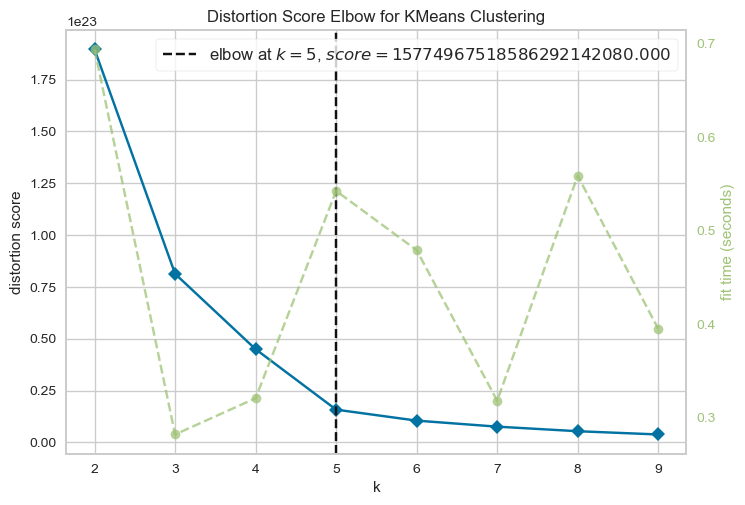

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [105]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [106]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glrlm_LowGrayLevelRunEmphasis_PET_b2
Correlation coefficient: 0.053518478713590514


1
Most correlated column: gldm_HighGrayLevelEmphasis_d_1_CT_b20
Correlation coefficient: 0.061791693422458445


2
Most correlated column: first_order_Maximum_CT
Correlation coefficient: 0.04633836690921384


3
Most correlated column: glcm_Autocorrelation_d_1_CT_c16
Correlation coefficient: 0.05627117308757032


4
Most correlated column: glszm_SmallAreaEmphasis_PET_b2
Correlation coefficient: 0.06340059435118155




In [107]:
selected_features

['glrlm_LowGrayLevelRunEmphasis_PET_b2',
 'gldm_HighGrayLevelEmphasis_d_1_CT_b20',
 'first_order_Maximum_CT',
 'glcm_Autocorrelation_d_1_CT_c16',
 'glszm_SmallAreaEmphasis_PET_b2']

In [108]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [109]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [110]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [111]:
X_new

,glrlm_LowGrayLevelRunEmphasis_PET_b2,gldm_HighGrayLevelEmphasis_d_1_CT_b20,first_order_Maximum_CT,glcm_Autocorrelation_d_1_CT_c16,glszm_SmallAreaEmphasis_PET_b2
0,0.133833,2017.837794,1763.283818,94.224171,0.411776
1,0.408878,1272.602864,1432.109636,119.164361,0.289067
2,0.298136,2671.911415,1685.931373,116.129599,0.167885
3,0.713169,2064.407252,1329.347515,164.460301,0.000244
4,0.310074,1763.529494,1197.225910,210.184151,0.137526
...,...,...,...,...,...
134,0.247042,842.189040,1267.959716,170.013539,0.125003
135,0.237124,1642.213124,1788.278096,80.363559,0.263911
136,0.111749,1551.393291,1478.297861,119.378154,0.294605
137,0.195533,1051.797561,1207.068493,197.371851,0.237261


In [112]:
X_new_std

,glrlm_LowGrayLevelRunEmphasis_PET_b2,gldm_HighGrayLevelEmphasis_d_1_CT_b20,first_order_Maximum_CT,glcm_Autocorrelation_d_1_CT_c16,glszm_SmallAreaEmphasis_PET_b2
0,0.148239,0.621409,0.379239,0.358521,0.887481
1,0.552620,0.386610,0.185193,0.461358,0.623011
2,0.389803,0.827485,0.333916,0.448845,0.361833
3,1.000000,0.636081,0.124981,0.648129,0.000525
4,0.407354,0.541285,0.047566,0.836665,0.296403
...,...,...,...,...,...
134,0.314682,0.251001,0.089012,0.671027,0.269413
135,0.300101,0.503062,0.393884,0.301369,0.568794
136,0.115769,0.474448,0.212256,0.462240,0.634948
137,0.238951,0.317042,0.053333,0.783835,0.511355


In [113]:
MAASTRO_new

,glrlm_LowGrayLevelRunEmphasis_PET_b2,gldm_HighGrayLevelEmphasis_d_1_CT_b20,first_order_Maximum_CT,glcm_Autocorrelation_d_1_CT_c16,glszm_SmallAreaEmphasis_PET_b2
0,0.108874,1483.666194,1226.795917,192.231457,0.224914
1,0.305178,2969.880344,1876.570382,97.043711,0.051926
2,0.186982,1981.654020,1269.217095,189.006881,0.195581
3,0.260511,3013.279652,1951.924395,89.769620,0.101441
4,0.205505,2192.606114,1646.853670,112.952004,0.088613
...,...,...,...,...,...
94,0.101497,1966.765954,2311.845731,48.979926,0.286434
95,0.157278,2656.699180,1299.857157,171.978518,0.065943
96,0.188714,2848.165242,1256.024949,197.769903,0.132816
97,0.179410,2056.250143,1668.742962,103.710049,0.274536


In [114]:
MAASTRO_new_std

,glrlm_LowGrayLevelRunEmphasis_PET_b2,gldm_HighGrayLevelEmphasis_d_1_CT_b20,first_order_Maximum_CT,glcm_Autocorrelation_d_1_CT_c16,glszm_SmallAreaEmphasis_PET_b2
0,0.111542,0.453109,0.064892,0.762640,0.484745
1,0.400156,0.921365,0.445617,0.370147,0.111913
2,0.226379,0.610008,0.089748,0.749344,0.421525
3,0.334485,0.935039,0.489770,0.340153,0.218631
4,0.253613,0.676472,0.311019,0.435743,0.190983
...,...,...,...,...,...
94,0.100697,0.605317,0.700660,0.171963,0.617336
95,0.182708,0.822692,0.107701,0.679130,0.142123
96,0.228927,0.883017,0.082019,0.785477,0.286251
97,0.215248,0.633511,0.323844,0.397635,0.591692


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [115]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 15:57:19,033] A new study created in memory with name: no-name-a6b5e2ed-0c50-47bf-92fc-08fbf7614404


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 15:57:19,271] A new study created in memory with name: no-name-a6ba9ac7-47e4-480a-a1a9-3d28e8ba1983


Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.6340425531914894
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.5450643776824035
[I 2024-04-14 15:57:19,264] Trial 0 finished with value: 0.5762361177339959 and parameters: {}. Best is trial 0 with value: 0.5762361177339959.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5762361177339959], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 19, 89555), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 19, 264022), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5762361177339959


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26711427015708006
Fold 2 IBS: 0.20768313235669297
Fold 3 IBS: 0.21200848343663917
Fold 4 IBS: 0.28063539429048184
Fold 5 IBS: 0.23451525526372308
[I 2024-04-14 15:57:19,581] Trial 0 finished with value: 0.24039130710092343 and parameters: {}. Best is trial 0 with value: 0.24039130710092343.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24039130710092343], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 19, 316512), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 19, 581527), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24039130710092343


In [116]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [117]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.576
train_ibs:  0.24


#### Test

In [118]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [119]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.588
IBS score: 0.228


In [120]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [121]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [122]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:57:19,778] A new study created in memory with name: no-name-6ad6ef7e-ca95-467a-bf64-838bf5e572f0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5099601593625498


[I 2024-04-14 15:57:19,949] A new study created in memory with name: no-name-6c44da36-6986-48ed-a3fb-65464a61e392


Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.5038022813688213
Fold 5 C-index: 0.5321888412017167
[I 2024-04-14 15:57:19,943] Trial 0 finished with value: 0.5628270698453014 and parameters: {}. Best is trial 0 with value: 0.5628270698453014.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5628270698453014], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 19, 813432), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 19, 943403), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5628270698453014


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2472471003774462
Fold 2 IBS: 0.23203988267501405
Fold 3 IBS: 0.22898186704117562
Fold 4 IBS: 0.24197477219881203
Fold 5 IBS: 0.2293955925555398
[I 2024-04-14 15:57:20,169] Trial 0 finished with value: 0.23592784296959754 and parameters: {}. Best is trial 0 with value: 0.23592784296959754.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784296959754], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 20, 2458), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 20, 168778), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784296959754


In [123]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [124]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.563
train_ibs:  0.236


#### Test

In [125]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [126]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.588


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [127]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [128]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:57:20,437] A new study created in memory with name: no-name-a0f290ac-e726-4669-afe3-aa295bb896a3


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 15:57:21,231] A new study created in memory with name: no-name-e19f8de0-3bc5-46dd-b445-62521cddf576


Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:21,224] Trial 0 finished with value: 0.5642798276136536 and parameters: {}. Best is trial 0 with value: 0.5642798276136536.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5642798276136536], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 20, 477506), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 21, 223926), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5642798276136536


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26664523253244504
Fold 2 IBS: 0.22223589505225969
Fold 3 IBS: 0.224901626962088
Fold 4 IBS: 0.2796942069355298
Fold 5 IBS: 0.23386007306039344
[I 2024-04-14 15:57:21,597] Trial 0 finished with value: 0.24546740690854318 and parameters: {}. Best is trial 0 with value: 0.24546740690854318.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24546740690854318], datetime_start=datetime.datetime(2024, 4, 14, 15, 57, 21, 266706), datetime_complete=datetime.datetime(2024, 4, 14, 15, 57, 21, 596989), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24546740690854318


In [129]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [130]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.564
train_ibs:  0.245


#### Test

In [131]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [132]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.588


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.228


In [133]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [134]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:57:22,026] A new study created in memory with name: no-name-8b44d92a-63b3-4b80-bd31-ebd4d85aedf1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.6550387596899225
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:22,363] Trial 0 finished with value: 0.5642365897125449 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5642365897125449.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.5957446808510638
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.5236051502145923
[I 2024-04-14 15:57:22,473] Trial 1 finished with value: 0.5573737851109123 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5642365897125449.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.6
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.5236051502145923
[I 2024-04-14 15:57:22,593] Trial 2 finished with value: 0.5574643926669353 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial

Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:28,825] Trial 24 finished with value: 0.5634613959140953 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.565138196712366.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.6
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:29,320] Trial 25 finished with value: 0.562610332084308 and parameters: {'l1_ratio': 0.6377859378373854}. Best is trial 6 with value: 0.565138196712366.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:29,696] Trial 26 finished with value: 0.5642798276136536 and parameters: {'l1_ratio': 0.9973554689957201}. Best is trial 6 with value: 0.565138196712366.
F

Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:35,717] Trial 48 finished with value: 0.5634613959140953 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 6 with value: 0.565138196712366.
Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 15:57:35,985] Trial 49 finished with value: 0.5634830148646496 and parameters: {'l1_ratio': 0.8808090855816024}. Best is trial 6 with value: 0.565138196712366.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5579399141630901
[I 2024-04-14 15:57:36,321] Trial 50 finished with value: 0.565138196712366 and parameters: {'l1_ratio': 0.9536910067044535}. Best is trial 6 with value: 0.565138196712366.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.647

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.2664797375117037
Fold 2 IBS: 0.224492373606354
Fold 3 IBS: 0.22565927264942523
Fold 4 IBS: 0.27939150896605625
Fold 5 IBS: 0.23371018167085802
[I 2024-04-14 15:57:48,919] Trial 0 finished with value: 0.24594661488087946 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24594661488087946.
Fold 1 IBS: 0.2474013241054494
Fold 2 IBS: 0.22821396295807733
Fold 3 IBS: 0.22720248869167325
Fold 4 IBS: 0.24414470990546303
Fold 5 IBS: 0.22831975772987564
[I 2024-04-14 15:57:49,113] Trial 1 finished with value: 0.2350564486781077 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2350564486781077.
Fold 1 IBS: 0.24731376243018763
Fold 2 IBS: 0.2288120568438669
Fold 3 IBS: 0.22750509032315627
Fold 4 IBS: 0.2436893921658823
Fold 5 IBS: 0.22850072312294048
[I 2024-04-14 15:57:49,257] Trial 2 finished with value: 0.23516420497720675 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.2350564486781077.

Fold 5 IBS: 0.22814282947953443
[I 2024-04-14 15:57:54,160] Trial 25 finished with value: 0.2349739035551471 and parameters: {'l1_ratio': 0.3486424175838364}. Best is trial 23 with value: 0.2349479505588438.
Fold 1 IBS: 0.26633144281742754
Fold 2 IBS: 0.22737540320341232
Fold 3 IBS: 0.22676074423646703
Fold 4 IBS: 0.24489734262928234
Fold 5 IBS: 0.22804922101753522
[I 2024-04-14 15:57:54,368] Trial 26 finished with value: 0.23868283078082486 and parameters: {'l1_ratio': 0.383151733256018}. Best is trial 23 with value: 0.2349479505588438.
Fold 1 IBS: 0.2664298373315767
Fold 2 IBS: 0.22541546184944078
Fold 3 IBS: 0.22599742756583122
Fold 4 IBS: 0.27930542949622067
Fold 5 IBS: 0.23374063716346977
[I 2024-04-14 15:57:54,697] Trial 27 finished with value: 0.2461777586813078 and parameters: {'l1_ratio': 0.5871946700391144}. Best is trial 23 with value: 0.2349479505588438.
Fold 1 IBS: 0.24728160130689483
Fold 2 IBS: 0.2291316029027293
Fold 3 IBS: 0.22764014579493305
Fold 4 IBS: 0.243469611791

Fold 5 IBS: 0.22790859795117419
[I 2024-04-14 15:58:00,058] Trial 50 finished with value: 0.23859067485733002 and parameters: {'l1_ratio': 0.4362382971907092}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.24753007532050933
Fold 2 IBS: 0.2276444371662239
Fold 3 IBS: 0.22690130612864043
Fold 4 IBS: 0.24464504859785696
Fold 5 IBS: 0.22813677449237435
[I 2024-04-14 15:58:00,315] Trial 51 finished with value: 0.23497152834112098 and parameters: {'l1_ratio': 0.3508476317874883}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.24754164603098397
Fold 2 IBS: 0.2276032440768974
Fold 3 IBS: 0.22687892561759532
Fold 4 IBS: 0.2446843568015027
Fold 5 IBS: 0.2281229547506535
[I 2024-04-14 15:58:00,505] Trial 52 finished with value: 0.23496622545552656 and parameters: {'l1_ratio': 0.3558957269793561}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.24741195497293483
Fold 2 IBS: 0.22815679950640075
Fold 3 IBS: 0.22717288928273063
Fold 4 IBS: 0.24419166488

Fold 2 IBS: 0.22784008031127131
Fold 3 IBS: 0.22700642764435242
Fold 4 IBS: 0.2444645301672713
Fold 5 IBS: 0.22820119573401407
[I 2024-04-14 15:58:04,781] Trial 75 finished with value: 0.23499838150084612 and parameters: {'l1_ratio': 0.32760301129949904}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.24757876648610302
Fold 2 IBS: 0.22747902099261866
Fold 3 IBS: 0.22681087551056706
Fold 4 IBS: 0.24480585767958293
Fold 5 IBS: 0.22808066619352224
[I 2024-04-14 15:58:05,061] Trial 76 finished with value: 0.2349510373724788 and parameters: {'l1_ratio': 0.3714652968797325}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.26639573596691657
Fold 2 IBS: 0.2273932420504266
Fold 3 IBS: 0.22676803567241388
Fold 4 IBS: 0.24488392905582215
Fold 5 IBS: 0.22805381150650453
[I 2024-04-14 15:58:05,273] Trial 77 finished with value: 0.23869895085041676 and parameters: {'l1_ratio': 0.38144036707956985}. Best is trial 40 with value: 0.2349468179778922.
Fold 1 IBS: 0.26640740

In [135]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [136]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.565
train_ibs:  0.235


#### Test

In [137]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [138]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.588


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.3778603841210768)

test_ibs:  0.226


In [139]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [140]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 15:58:10,215] A new study created in memory with name: no-name-2e4126d8-722e-4d6d-b5f8-ebd1ad789022


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4960159362549801
Fold 2 C-index: 0.6569767441860465
Fold 3 C-index: 0.6021276595744681
Fold 4 C-index: 0.5627376425855514
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 15:58:14,793] Trial 0 finished with value: 0.5605673046747156 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5605673046747156.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.624031007751938
Fold 3 C-index: 0.5361702127659574
Fold 4 C-index: 0.55893536121673
Fold 5 C-index: 0.5450643776824035
[I 2024-04-14 15:58:18,525] Trial 1 finished with value: 0.5635971639949595 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 15:58:51,559] Trial 15 finished with value: 0.5 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 106, 'oob_score': True, 'max_samples': 0.11898640989044829, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.215934984641199, 'warm_start': True}. Best is trial 14 with value: 0.6325118466113775.
Fold 1 C-index: 0.5159362549800797
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.5765957446808511
Fold 4 C-index: 0.6254752851711026
Fold 5 C-index: 0.5987124463519313
[I 2024-04-14 15:58:51,815] Trial 16 finished with value: 0.5982276671670255 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 7, 'n_estimators': 5, 'oob_score': True, 'max_samples': 0.8042336624162363, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.38631316134058014, 'warm_start': True}. Best is trial 14 with value: 0.63251

Fold 1 C-index: 0.5039840637450199
Fold 2 C-index: 0.6763565891472868
Fold 3 C-index: 0.6978723404255319
Fold 4 C-index: 0.6026615969581749
Fold 5 C-index: 0.5150214592274678
[I 2024-04-14 15:59:03,301] Trial 31 finished with value: 0.5991792099006963 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 19, 'min_samples_leaf': 20, 'max_depth': 19, 'n_estimators': 180, 'oob_score': True, 'max_samples': 0.5362821371931331, 'max_features': None, 'min_weight_fraction_leaf': 0.07357737655475827, 'warm_start': True}. Best is trial 14 with value: 0.6325118466113775.
Fold 1 C-index: 0.48804780876494025
Fold 2 C-index: 0.6957364341085271
Fold 3 C-index: 0.7425531914893617
Fold 4 C-index: 0.6349809885931559
Fold 5 C-index: 0.5321888412017167
[I 2024-04-14 15:59:04,163] Trial 32 finished with value: 0.6187014528315403 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 18, 'max_depth': 13, 'n_estimators': 140, 'oob_score': True, 'max_samples': 0.69914956657302

...

Fold 1 IBS: 0.24656698463199173
Fold 2 IBS: 0.21042325800449532
Fold 3 IBS: 0.2248079594486099
Fold 4 IBS: 0.2537940464689902
Fold 5 IBS: 0.23554259172607742
[I 2024-04-14 16:02:09,456] Trial 32 finished with value: 0.23422696805603288 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 3, 'n_estimators': 324, 'oob_score': False, 'max_samples': 0.9502203520505428, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17033334212155432}. Best is trial 22 with value: 0.23250029383188683.
Fold 1 IBS: 0.24484811566710984
Fold 2 IBS: 0.2112546286274112
Fold 3 IBS: 0.22592608689378385
Fold 4 IBS: 0.2544594200721292
Fold 5 IBS: 0.23219202624181348
[I 2024-04-14 16:02:13,008] Trial 33 finished with value: 0.2337360555004495 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 13, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 403, 'oob_score': False, 'max_samples': 0.834951568710347, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 1 IBS: 0.24668037377499327
Fold 2 IBS: 0.2322608389126047
Fold 3 IBS: 0.2294827355681336
Fold 4 IBS: 0.24142157586818422
Fold 5 IBS: 0.2303897601180458
[I 2024-04-14 16:03:00,044] Trial 48 finished with value: 0.23604705684839233 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 270, 'oob_score': False, 'max_samples': 0.5395817423078306, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.39308816597832114}. Best is trial 22 with value: 0.23250029383188683.
Fold 1 IBS: 0.24734377377411182
Fold 2 IBS: 0.2150647790465198
Fold 3 IBS: 0.21955476180347203
Fold 4 IBS: 0.24585883440462547
Fold 5 IBS: 0.23895703595950327
[I 2024-04-14 16:03:03,686] Trial 49 finished with value: 0.23335583699764645 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 12, 'min_samples_leaf': 9, 'max_depth': 7, 'n_estimators': 367, 'oob_score': True, 'max_samples': 0.8701465740758021, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 1 IBS: 0.24758075930859677
Fold 2 IBS: 0.2163157390735758
Fold 3 IBS: 0.21904124508508196
Fold 4 IBS: 0.24176184164750933
Fold 5 IBS: 0.23775631091028393
[I 2024-04-14 16:03:58,500] Trial 64 finished with value: 0.23249117920500958 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 444, 'oob_score': True, 'max_samples': 0.65359113725185, 'max_features': None, 'min_weight_fraction_leaf': 0.3089914685735003}. Best is trial 63 with value: 0.23236762996732963.
Fold 1 IBS: 0.24769972249783642
Fold 2 IBS: 0.21604167416456121
Fold 3 IBS: 0.21889555300737853
Fold 4 IBS: 0.24155458833744753
Fold 5 IBS: 0.23761229765079694
[I 2024-04-14 16:04:03,149] Trial 65 finished with value: 0.23236076713160408 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 445, 'oob_score': True, 'max_samples': 0.6625687264192711, 'max_features': None, 'min_weight_fraction_leaf'

Fold 1 IBS: 0.24628368180656585
Fold 2 IBS: 0.23216255264949376
Fold 3 IBS: 0.22963904354964518
Fold 4 IBS: 0.2414739647229855
Fold 5 IBS: 0.23026686854837097
[I 2024-04-14 16:05:20,380] Trial 80 finished with value: 0.23596522225541222 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 445, 'oob_score': True, 'max_samples': 0.7067242004030547, 'max_features': None, 'min_weight_fraction_leaf': 0.42891809301890427}. Best is trial 65 with value: 0.23236076713160408.
Fold 1 IBS: 0.24912596614097313
Fold 2 IBS: 0.21419392633409734
Fold 3 IBS: 0.21840487843773232
Fold 4 IBS: 0.24018575319659255
Fold 5 IBS: 0.24369533253986408
[I 2024-04-14 16:05:25,487] Trial 81 finished with value: 0.23312117132985186 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 12, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 458, 'oob_score': True, 'max_samples': 0.7286232239477684, 'max_features': None, 'min_weight_fraction_le

Fold 1 IBS: 0.24635382170721337
Fold 2 IBS: 0.23214630305294084
Fold 3 IBS: 0.22956711510758523
Fold 4 IBS: 0.24155453396533838
Fold 5 IBS: 0.23022598859007215
[I 2024-04-14 16:06:25,425] Trial 96 finished with value: 0.23596955248463 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 17, 'n_estimators': 376, 'oob_score': True, 'max_samples': 0.9390031902949338, 'max_features': None, 'min_weight_fraction_leaf': 0.4709603466468572}. Best is trial 95 with value: 0.23166692490774557.
Fold 1 IBS: 0.24756961480580778
Fold 2 IBS: 0.21545729825417093
Fold 3 IBS: 0.21818049472625162
Fold 4 IBS: 0.23983935137792312
Fold 5 IBS: 0.24052144526912037
[I 2024-04-14 16:06:29,236] Trial 97 finished with value: 0.23231364088665477 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 410, 'oob_score': True, 'max_samples': 0.986393083706084, 'max_features': None, 'min_weight_fraction_leaf':

In [141]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [142]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.803
train_ibs:  0.232


#### Test

In [143]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [144]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='auto', max_leaf_nodes=14,
                     max_samples=0.8189493021650692, min_samples_leaf=2,
                     min_samples_split=12,
                     min_weight_fraction_leaf=0.015994851324148483,
                     n_estimators=233, random_state=123, warm_start=True)

test_cindex:  0.559


RandomSurvivalForest(max_depth=17, max_features=None, max_leaf_nodes=15,
                     max_samples=0.9665622592574186, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.4582223714360093,
                     n_estimators=413, oob_score=True, random_state=123)

test_ibs:  0.232


In [145]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [146]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:06:38,535] A new study created in memory with name: no-name-c5d5ad93-7b43-41c8-bc35-1aebfdc3fad7


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5298804780876494
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6463878326996197
Fold 5 C-index: 0.5708154506437768
[I 2024-04-14 16:06:39,160] Trial 0 finished with value: 0.6416879051808158 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6416879051808158.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:06:40,904] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.6045627376425855
Fold 5 C-index: 0.5150214592274678
[I 2024-04-14 16:07:03,166] Trial 15 finished with value: 0.6054844564202574 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6637540277720066.
Fold 1 C-index: 0.5039840637450199
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.6893617021276596
Fold 4 C-index: 0.5627376425855514
Fold 5 C-index: 0.5686695278969958
[I 2024-04-14 16:07:04,198] Trial 16 finished with value: 0.6060358585888748 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_fea

Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.7186311787072244
Fold 5 C-index: 0.6223175965665236
[I 2024-04-14 16:07:18,363] Trial 30 finished with value: 0.6762373798286213 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 278, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.05879574792157449}. Best is trial 23 with value: 0.6861181640129439.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.688212927756654
Fold 5 C-index: 0.6008583690987125
[I 2024-04-14 16:07:19,240] Trial 31 finished with value: 0.6611458645025843 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 281, 'oob_score': False, 'warm_start': True, 'max_features': N

...

Fold 1 IBS: 0.24493754756002886
Fold 2 IBS: 0.22553507195465983
Fold 3 IBS: 0.2246081947009921
Fold 4 IBS: 0.24509326950575464
Fold 5 IBS: 0.23205346773392854
[I 2024-04-14 16:08:41,665] Trial 30 finished with value: 0.2344455102910728 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 344, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6268142217016631, 'min_weight_fraction_leaf': 0.09023089007695154}. Best is trial 12 with value: 0.23352750706454622.
Fold 1 IBS: 0.2444798036207479
Fold 2 IBS: 0.22414440691763685
Fold 3 IBS: 0.22423412274951227
Fold 4 IBS: 0.24723085441645906
Fold 5 IBS: 0.23071192429009138
[I 2024-04-14 16:08:44,202] Trial 31 finished with value: 0.2341602223988895 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 14, 'n_estimators': 420, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5

Fold 1 IBS: 0.2447258646183919
Fold 2 IBS: 0.2261733405639749
Fold 3 IBS: 0.22559262936896912
Fold 4 IBS: 0.24409673089084663
Fold 5 IBS: 0.23121113043114191
[I 2024-04-14 16:09:11,842] Trial 45 finished with value: 0.2343599391746649 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 12, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 469, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.49900423273335853, 'min_weight_fraction_leaf': 0.10742749503456472}. Best is trial 42 with value: 0.2331041329121742.
Fold 1 IBS: 0.2458350240058735
Fold 2 IBS: 0.22281793590365026
Fold 3 IBS: 0.22098084354264072
Fold 4 IBS: 0.24959391321002478
Fold 5 IBS: 0.23030754678179813
[I 2024-04-14 16:09:12,952] Trial 46 finished with value: 0.2339070526887975 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 236, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 

Fold 2 IBS: 0.22968881465954366
Fold 3 IBS: 0.2289894223846552
Fold 4 IBS: 0.24240996814596585
Fold 5 IBS: 0.23048101785856476
[I 2024-04-14 16:09:38,271] Trial 60 finished with value: 0.23536213200703754 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 12, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 58, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.7635232186669584, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 42 with value: 0.2331041329121742.
Fold 1 IBS: 0.24905488202175827
Fold 2 IBS: 0.21924481338746946
Fold 3 IBS: 0.21637644773393216
Fold 4 IBS: 0.26072752080741807
Fold 5 IBS: 0.22576824885466057
[I 2024-04-14 16:09:40,527] Trial 61 finished with value: 0.2342343825610477 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'max_depth': 7, 'n_estimators': 496, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8152587619088552, 'min_weight_frac

Fold 1 IBS: 0.24994253814450215
Fold 2 IBS: 0.22033451512108657
Fold 3 IBS: 0.2124143330417655
Fold 4 IBS: 0.25422143994769153
Fold 5 IBS: 0.22542386365807426
[I 2024-04-14 16:10:05,080] Trial 75 finished with value: 0.232467337982624 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 474, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9096892435929536, 'min_weight_fraction_leaf': 0.0012536868268459688}. Best is trial 64 with value: 0.23201254641180205.
Fold 1 IBS: 0.24794405892803612
Fold 2 IBS: 0.219910334331737
Fold 3 IBS: 0.2175505388580945
Fold 4 IBS: 0.2536575357506297
Fold 5 IBS: 0.22679390784026976
[I 2024-04-14 16:10:06,803] Trial 76 finished with value: 0.2331712751417534 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 481, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.94

Fold 1 IBS: 0.24574653969776014
Fold 2 IBS: 0.226559204100091
Fold 3 IBS: 0.22468085545793628
Fold 4 IBS: 0.244435533002918
Fold 5 IBS: 0.22996785538730974
[I 2024-04-14 16:10:31,431] Trial 90 finished with value: 0.23427799752920303 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 472, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8516305193282283, 'min_weight_fraction_leaf': 0.09353596780419524}. Best is trial 79 with value: 0.23175407165735468.
Fold 1 IBS: 0.24761062008724338
Fold 2 IBS: 0.21920628487462673
Fold 3 IBS: 0.2123881783221893
Fold 4 IBS: 0.2565950597483591
Fold 5 IBS: 0.22434088818237227
[I 2024-04-14 16:10:33,328] Trial 91 finished with value: 0.23202820624295817 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 477, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9

In [147]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [148]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.757
train_ibs:  0.232


#### Test

In [149]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [150]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features='auto', max_leaf_nodes=14,
                   max_samples=0.9308807364305056, min_samples_leaf=2,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.01173290087081252,
                   n_estimators=141, random_state=123, warm_start=True)

C-index score: 0.583


ExtraSurvivalTrees(max_depth=8, max_features='auto', max_leaf_nodes=4,
                   max_samples=0.7896400935352503, min_samples_leaf=1,
                   min_samples_split=12,
                   min_weight_fraction_leaf=0.00022399567911078817,
                   n_estimators=444, random_state=123)

IBS: 0.222


In [151]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [152]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:10:49,862] A new study created in memory with name: no-name-28da6a6f-e298-4dcb-a0d6-1eb657f55dc0


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:10:57,481] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:11:01,618] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:12:36,318] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5608023413817993.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:12:51,802] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:14:17,795] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5608023413817993.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:14:31,472] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:47:34,708] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5394364973391026, 'learning_rate': 0.06329497999485652, 'dropout_rate': 0.759135104769283, 'n_estimators': 331, 'criterion': 'squared_error', 'ccp_alpha': 4.700581724781291, 'min_weight_fraction_leaf': 0.03988747270681184, 'max_features': 'log2', 'min_impurity_decrease': 2.131010449050355e-05, 'validation_fraction': 0.7183631491601807, 'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 16}. Best is trial 9 with value: 0.23592534234634566.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:48:38,269] Trial 46 finished with value: 0.23592784351233073 and parameters: {'

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:50:03,638] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.37873621687218656, 'learning_rate': 0.005987509507317608, 'dropout_rate': 0.7022177203571731, 'n_estimators': 117, 'criterion': 'friedman_mse', 'ccp_alpha': 0.2574556825023037, 'min_weight_fraction_leaf': 0.26567772906898, 'max_features': None, 'min_impurity_decrease': 0.00012396934505728752, 'validation_fraction': 0.4096992615859676, 'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 6}. Best is trial 53 with value: 0.23588640637778044.
Fold 1 IBS: 0.2472177978988655
Fold 2 IBS: 0.23195125528222607
Fold 3 IBS: 0.22892131069640026
Fold 4 IBS: 0.2419915048906965
Fold 5 IBS: 0.22942124016907706
[I 2024-04-14 16:50:05,980] Trial 57 finished with value: 0.23590062178745308 and parameters: {'subsample': 0.1994606195634132, 'le

Fold 3 IBS: 0.22879407733926763
Fold 4 IBS: 0.24202145093529007
Fold 5 IBS: 0.22945951031242035
[I 2024-04-14 16:50:41,787] Trial 67 finished with value: 0.2358604881397762 and parameters: {'subsample': 0.2735188296027359, 'learning_rate': 0.019625536517399393, 'dropout_rate': 0.8235817860590289, 'n_estimators': 45, 'criterion': 'friedman_mse', 'ccp_alpha': 0.04593415370943682, 'min_weight_fraction_leaf': 0.19405871505081354, 'max_features': None, 'min_impurity_decrease': 0.00724212177995058, 'validation_fraction': 0.4923570612268152, 'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 11, 'max_depth': 4}. Best is trial 67 with value: 0.2358604881397762.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:50:42,292] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.27785634551211125, 'learning_rate': 0.0201283854142366

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:50:56,192] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.42922018997538286, 'learning_rate': 0.014610988323250492, 'dropout_rate': 0.9944936917224156, 'n_estimators': 22, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5928871235184483, 'min_weight_fraction_leaf': 0.19304857841587608, 'max_features': None, 'min_impurity_decrease': 0.054818528036710466, 'validation_fraction': 0.38046638604203564, 'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 9, 'max_depth': 1}. Best is trial 67 with value: 0.2358604881397762.
Fold 1 IBS: 0.24721044661405575
Fold 2 IBS: 0.23193389019276406
Fold 3 IBS: 0.22889285571923326
Fold 4 IBS: 0.24198491756688703
Fold 5 IBS: 0.22941062960664987
[I 2024-04-14 16:50:57,799] Trial 79 finished with value: 0.23588654793991798 and parameters: {'subsample': 0.36012863254141936, 'learning_rate': 0.011013293780642953, 'dropout_rate': 0.7773562869720088, 'n_estimators': 73, 'c

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:51:19,993] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.39716912192884773, 'learning_rate': 0.032646856895335405, 'dropout_rate': 0.8673523664134214, 'n_estimators': 159, 'criterion': 'friedman_mse', 'ccp_alpha': 0.24976962641059486, 'min_weight_fraction_leaf': 0.2103379966362654, 'max_features': None, 'min_impurity_decrease': 0.03731247188694396, 'validation_fraction': 0.4474209392116476, 'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 2}. Best is trial 67 with value: 0.2358604881397762.
Fold 1 IBS: 0.24723980213051466
Fold 2 IBS: 0.2320033492450338
Fold 3 IBS: 0.2289380139958503
Fold 4 IBS: 0.24201369407692624
Fold 5 IBS: 0.2294243975591708
[I 2024-04-14 16:51:22,537] Trial 91 finished with value: 0.23592385140149913 and parameters: {'subsam

In [153]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [154]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.561
train_ibs:  0.236


#### Test

In [155]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [156]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.525


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0043718660826469555,
                                 dropout_rate=0.9031932935045044,
                                 learning_rate=0.018548325980124177,
                                 max_depth=5, max_leaf_nodes=8,
                                 min_impurity_decrease=0.06077759154646059,
                                 min_samples_leaf=11, min_samples_split=12,
                                 min_weight_fraction_leaf=0.2672362923820807,
                                 n_estimators=93, random_state=123,
                                 subsample=0.519103549190335,
                                 validation_fraction=0.572588797752273)

IBS: 0.229


In [157]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [158]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:51:53,799] A new study created in memory with name: no-name-d84e0a6d-4d8a-4afa-aea9-a46811d50d5d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 16:51:54,892] Trial 0 finished with value: 0.605489971201168 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.605489971201168.
Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 16:52:04,380] Trial 1 finished with value: 0.6047147774027184 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.605489971201168.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7829787234042553
Fold 4 C

Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 16:52:41,565] Trial 19 finished with value: 0.5972000615714395 and parameters: {'subsample': 0.37409179704137924, 'dropout_rate': 0.19352385445052883, 'n_estimators': 84, 'learning_rate': 0.036212385990032875}. Best is trial 17 with value: 0.6063410350309553.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.5493562231759657
[I 2024-04-14 16:52:46,912] Trial 20 finished with value: 0.6006660002271318 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.3398953929911783, 'n_estimators': 331, 'learning_rate': 0.017331004877487094}. Best is trial 17 with value: 0.6063410350309553.
Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.49809885931558

Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5493562231759657
[I 2024-04-14 16:53:25,286] Trial 38 finished with value: 0.602353390362021 and parameters: {'subsample': 0.3030025464899834, 'dropout_rate': 0.28067084872714065, 'n_estimators': 182, 'learning_rate': 0.025329708851985266}. Best is trial 17 with value: 0.6063410350309553.
Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.49809885931558934
Fold 5 C-index: 0.5536480686695279
[I 2024-04-14 16:53:25,938] Trial 39 finished with value: 0.6047147774027184 and parameters: {'subsample': 0.8313344686833679, 'dropout_rate': 0.35318516226602215, 'n_estimators': 91, 'learning_rate': 0.06078607575212151}. Best is trial 17 with value: 0.6063410350309553.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.7829787234042553

...

Fold 3 IBS: 0.22834769221461246
Fold 4 IBS: 0.24896183160687785
Fold 5 IBS: 0.2268416019249348
[I 2024-04-14 16:55:31,232] Trial 19 finished with value: 0.23608386126568764 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 14 with value: 0.23356002988438157.
Fold 1 IBS: 0.2540053173555925
Fold 2 IBS: 0.2190670929272956
Fold 3 IBS: 0.21298645158124893
Fold 4 IBS: 0.2542164577077433
Fold 5 IBS: 0.225115549423201
[I 2024-04-14 16:55:32,454] Trial 20 finished with value: 0.23307817379901624 and parameters: {'subsample': 0.8452240769714876, 'dropout_rate': 0.5558690358940764, 'n_estimators': 145, 'learning_rate': 0.017331004877487094}. Best is trial 20 with value: 0.23307817379901624.
Fold 1 IBS: 0.2528939863918576
Fold 2 IBS: 0.22008089524518168
Fold 3 IBS: 0.2142324407088966
Fold 4 IBS: 0.25286495116251945
Fold 5 IBS: 0.2253027462052497
[I 2024-04-14 16:55:33,736] Trial 21 finishe

Fold 3 IBS: 0.19836780664580922
Fold 4 IBS: 0.27668116605659254
Fold 5 IBS: 0.22719383132152796
[I 2024-04-14 16:56:08,527] Trial 38 finished with value: 0.23714118907629672 and parameters: {'subsample': 0.7349733890162259, 'dropout_rate': 0.4229856903785987, 'n_estimators': 117, 'learning_rate': 0.04635051641975055}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.26197970854305164
Fold 2 IBS: 0.21437799424414336
Fold 3 IBS: 0.20402078351959343
Fold 4 IBS: 0.2637811228898344
Fold 5 IBS: 0.22497443389539107
[I 2024-04-14 16:56:11,344] Trial 39 finished with value: 0.23382680861840283 and parameters: {'subsample': 0.8848555027492468, 'dropout_rate': 0.2749781655874512, 'n_estimators': 194, 'learning_rate': 0.01918522661399938}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.43110648074195174
Fold 2 IBS: 0.3309142960257754
Fold 3 IBS: 0.16549866156672444
Fold 4 IBS: 0.46120546476740465
Fold 5 IBS: 0.33661961368229454
[I 2024-04-14 16:56:18,204] Trial 40 f

Fold 4 IBS: 0.24896986539000118
Fold 5 IBS: 0.2268933716844037
[I 2024-04-14 16:56:27,479] Trial 57 finished with value: 0.23482465764924462 and parameters: {'subsample': 0.24234604951696737, 'dropout_rate': 0.8542709284911807, 'n_estimators': 60, 'learning_rate': 0.03130407565308407}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.30019766722252
Fold 2 IBS: 0.20444919979527354
Fold 3 IBS: 0.1838594153903522
Fold 4 IBS: 0.29939888105913487
Fold 5 IBS: 0.2397256370122723
[I 2024-04-14 16:56:29,161] Trial 58 finished with value: 0.24552616009591058 and parameters: {'subsample': 0.7679047380148646, 'dropout_rate': 0.6617929741009889, 'n_estimators': 176, 'learning_rate': 0.049620567327876584}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.2528601550798128
Fold 2 IBS: 0.219830352780567
Fold 3 IBS: 0.21864817166462147
Fold 4 IBS: 0.2519533738782524
Fold 5 IBS: 0.22528786449388596
[I 2024-04-14 16:56:31,435] Trial 59 finished with value: 0.23371598357942794

Fold 4 IBS: 0.24959541155298712
Fold 5 IBS: 0.22590353664084564
[I 2024-04-14 16:56:46,236] Trial 76 finished with value: 0.23315459811190858 and parameters: {'subsample': 0.8673267400719322, 'dropout_rate': 0.8942082568312547, 'n_estimators': 94, 'learning_rate': 0.01851910601248799}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.25473629662895964
Fold 2 IBS: 0.21853756661630314
Fold 3 IBS: 0.21034547299653544
Fold 4 IBS: 0.2557524715119188
Fold 5 IBS: 0.22506983804641323
[I 2024-04-14 16:56:47,076] Trial 77 finished with value: 0.23288832916002605 and parameters: {'subsample': 0.978485475694644, 'dropout_rate': 0.9243539710160009, 'n_estimators': 109, 'learning_rate': 0.024079459857898118}. Best is trial 31 with value: 0.23285294014374397.
Fold 1 IBS: 0.26288187307116195
Fold 2 IBS: 0.21363816129271096
Fold 3 IBS: 0.20251488954706762
Fold 4 IBS: 0.26506779294584215
Fold 5 IBS: 0.2250778821378266
[I 2024-04-14 16:56:48,658] Trial 78 finished with value: 0.23383611979

Fold 5 IBS: 0.22511651246482964
[I 2024-04-14 16:57:07,491] Trial 95 finished with value: 0.23292905936707195 and parameters: {'subsample': 0.8611982170424028, 'dropout_rate': 0.9726979903695653, 'n_estimators': 77, 'learning_rate': 0.03242695631273248}. Best is trial 81 with value: 0.2328500494658285.
Fold 1 IBS: 0.2547176240054217
Fold 2 IBS: 0.21851460334311393
Fold 3 IBS: 0.21093078270870244
Fold 4 IBS: 0.2559629462703876
Fold 5 IBS: 0.2250390914940568
[I 2024-04-14 16:57:08,754] Trial 96 finished with value: 0.23303300956433654 and parameters: {'subsample': 0.9037392212047205, 'dropout_rate': 0.9806455021652567, 'n_estimators': 114, 'learning_rate': 0.022946127143719193}. Best is trial 81 with value: 0.2328500494658285.
Fold 1 IBS: 0.26177102644458683
Fold 2 IBS: 0.21393808709507603
Fold 3 IBS: 0.20365474806249062
Fold 4 IBS: 0.2639128956756857
Fold 5 IBS: 0.22496648642273595
[I 2024-04-14 16:57:10,227] Trial 97 finished with value: 0.23364864874011498 and parameters: {'subsample'

In [159]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [160]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.606
train_ibs:  0.233


#### Test

In [161]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [162]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.23930666550173862,
                                              learning_rate=0.04038139411211823,
                                              n_estimators=85, random_state=123,
                                              subsample=0.6278318159798674)

C-index score: 0.601


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9478485138274121,
                                              learning_rate=0.026444515888771763,
                                              n_estimators=85, random_state=123,
                                              subsample=0.8399767173532761)

IBS: 0.225


In [163]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [164]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.803,1.0
ExtraSurvivalTrees,0.757,2.0
ComponentwiseGradientBoosting,0.606,3.0
CoxPH,0.576,4.0
CoxElastic,0.565,5.0
CoxLasso,0.564,6.0
CoxRidge,0.563,7.0
GradientBoosting,0.561,8.0


In [165]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.232,1.5
ExtraSurvivalTrees,0.232,1.5
ComponentwiseGradientBoosting,0.233,3.0
CoxElastic,0.235,4.0
CoxRidge,0.236,5.5
GradientBoosting,0.236,5.5
CoxPH,0.240,7.0
CoxLasso,0.245,8.0


In [166]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.601,1.0
CoxPH,0.588,3.5
CoxRidge,0.588,3.5
CoxLasso,0.588,3.5
CoxElastic,0.588,3.5
ExtraSurvivalTrees,0.583,6.0
Randomsurvivalforest,0.559,7.0
GradientBoosting,0.525,8.0


In [167]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.222,1.0
ComponentwiseGradientBoosting,0.225,2.0
CoxElastic,0.226,3.0
CoxPH,0.228,4.5
CoxLasso,0.228,4.5
CoxRidge,0.229,6.5
GradientBoosting,0.229,6.5
Randomsurvivalforest,0.232,8.0


In [168]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/minmax/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_minmax_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [169]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
